# Milestone 3: Mott Transition Scan

Scan U from weak to strong coupling and observe:
- Z(U) decreasing toward the Mott transition
- Spectral weight transfer from quasiparticle peak to Hubbard bands
- Gap opening in the insulating phase

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from dmft.config import DMFTParams
from dmft.solvers.ipt import IPTSolver
from dmft.dmft_loop import dmft_loop
from dmft.observables import spectral_function_from_poles
from dmft.plotting import plot_z_vs_u

## 1. Z(U) scan with IPT

U=0.50: Z=0.9049
U=0.75: Z=0.8069
U=1.00: Z=0.6975
U=1.25: Z=0.5897
U=1.50: Z=0.4902
U=1.75: Z=0.4013
U=2.00: Z=0.3220
U=2.25: Z=0.2464
U=2.50: Z=0.0047
U=2.75: Z=0.0034
U=3.00: Z=0.0026
U=3.25: Z=0.0021
U=3.50: Z=0.0017
U=3.75: Z=0.0014
U=4.00: Z=0.0012
U=4.25: Z=0.0010


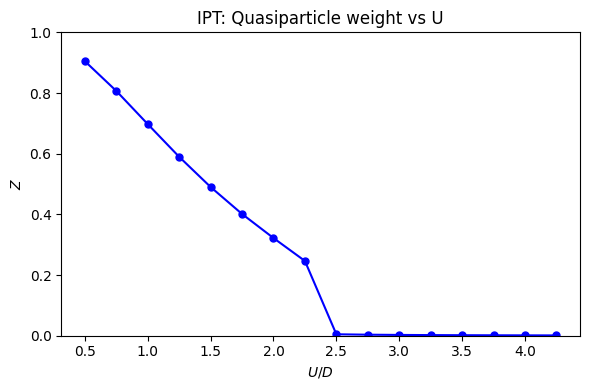

In [2]:
U_values = np.arange(0.5, 4.5, 0.25)
Z_values = []
results = {}

for U in U_values:
    p = DMFTParams.half_filling(U=U, beta=50.0, n_matsubara=1024, M_g=2, M_h=2)
    p.max_iter = 100; p.mix = 0.3
    r = dmft_loop(p, IPTSolver(), verbose=False)
    Z_values.append(r['Z'])
    results[U] = r
    print(f'U={U:.2f}: Z={r["Z"]:.4f}')

fig = plot_z_vs_u(U_values, Z_values, 'IPT: Quasiparticle weight vs U')
plt.show()

## 2. Spectral function evolution

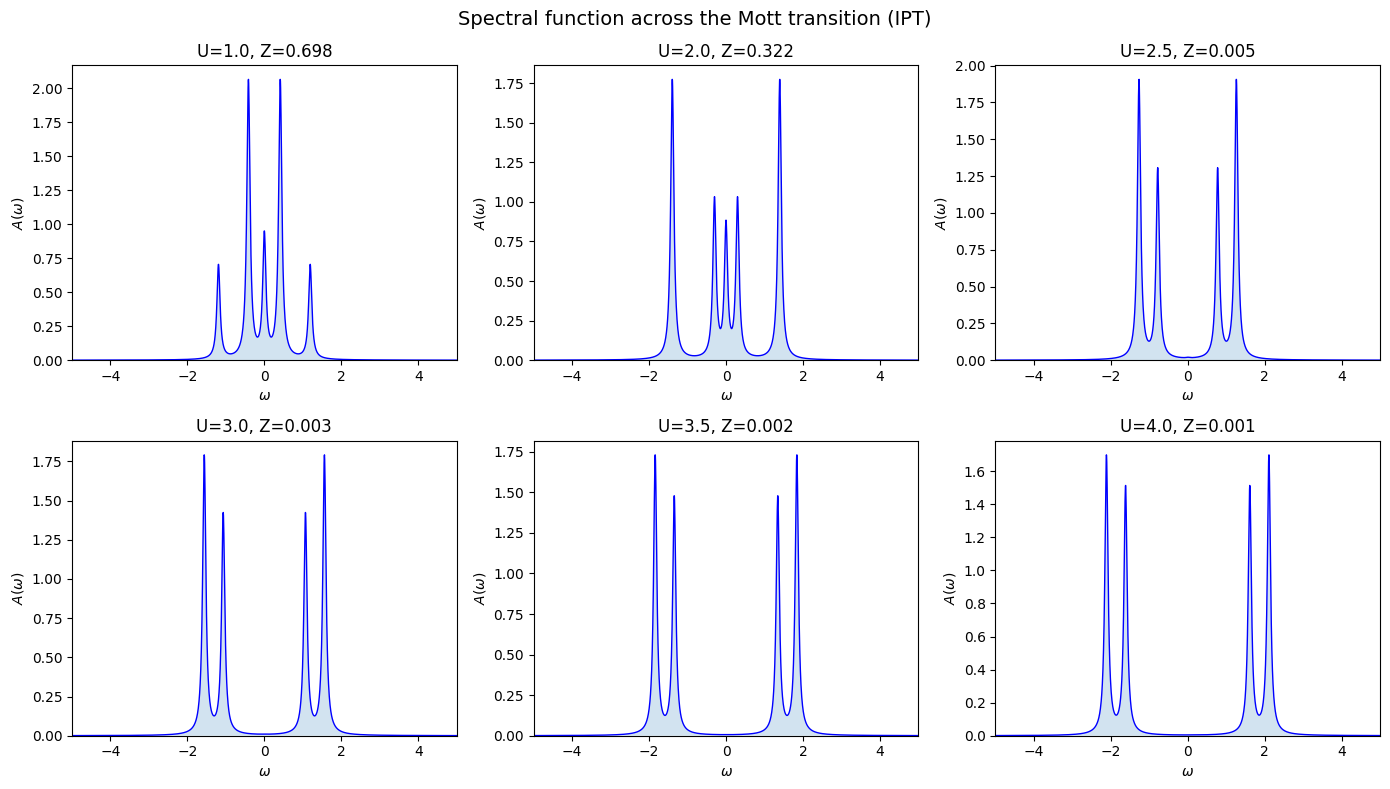

In [3]:
omega = np.linspace(-5, 5, 2000)
U_plot = [1.0, 2.0, 2.5, 3.0, 3.5, 4.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, U in zip(axes.flat, U_plot):
    if U not in results:
        # Find closest
        U = min(results.keys(), key=lambda x: abs(x - U))
    r = results[U]
    p = r['poles']
    A = spectral_function_from_poles(omega, U/2, 0.0, p.V, p.eps, p.W, p.eta, p.sigma_inf, 0.05)
    ax.plot(omega, A, 'b-', lw=1)
    ax.fill_between(omega, 0, A, alpha=0.2)
    ax.set_title(f'U={U:.1f}, Z={r["Z"]:.3f}')
    ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$A(\omega)$')
    ax.set_xlim(-5, 5); ax.set_ylim(bottom=0)

plt.suptitle('Spectral function across the Mott transition (IPT)', fontsize=14)
plt.tight_layout(); plt.show()

## 3. Waterfall plot

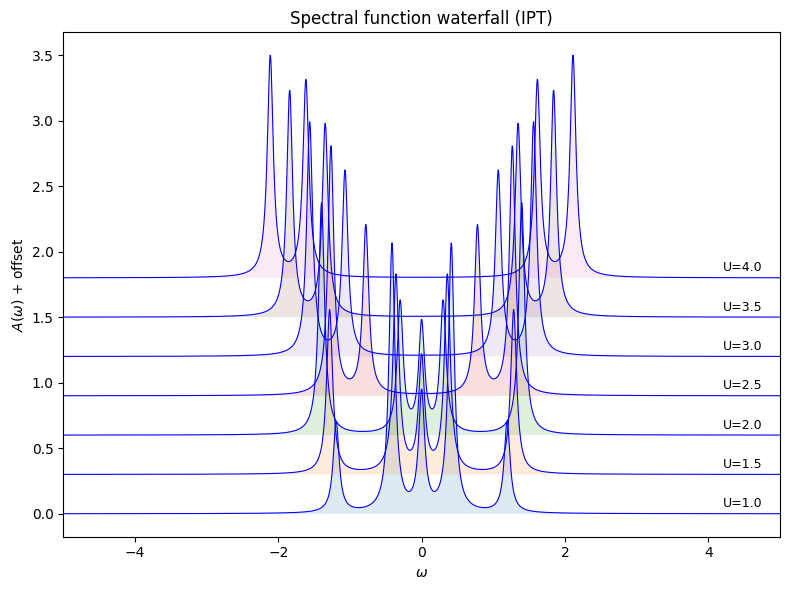

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
U_waterfall = np.arange(1.0, 4.1, 0.5)

for i, U in enumerate(U_waterfall):
    U_key = min(results.keys(), key=lambda x: abs(x - U))
    r = results[U_key]
    p = r['poles']
    A = spectral_function_from_poles(omega, U_key/2, 0.0, p.V, p.eps, p.W, p.eta, p.sigma_inf, 0.05)
    offset = i * 0.3
    ax.plot(omega, A + offset, 'b-', lw=0.8)
    ax.fill_between(omega, offset, A + offset, alpha=0.15)
    ax.text(4.2, offset + 0.05, f'U={U_key:.1f}', fontsize=9)

ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$A(\omega)$ + offset')
ax.set_title('Spectral function waterfall (IPT)')
ax.set_xlim(-5, 5)
plt.tight_layout(); plt.show()